
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://raw.githubusercontent.com/anferivera/Fisica_Computacional_1/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Placa conductora" width="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

def Laplace2D_FDM(V_ini, tol):
    V = V_ini.copy()
    error = 1.0
    iters = 0
    
    while error > tol:
        V_old = V.copy()
        
        V[1:-1, 1:-1] = 0.25 * (V_old[2:, 1:-1] + V_old[:-2, 1:-1] + V_old[1:-1, 2:] + V_old[1:-1, :-2])
        
        error = np.max(np.abs(V - V_old))
        iters += 1
        
    return V, iters, error

def Diffusion2D_FDM(V_ini, D, dx, dt, t_final):
    V = V_ini.copy()
    n_steps = int(t_final / dt)
    rx = D * dt / (dx**2)
    
    for _ in range(n_steps):
        V_old = V.copy()
        V[1:-1, 1:-1] = V_old[1:-1, 1:-1] + rx * (
            V_old[2:, 1:-1] + V_old[:-2, 1:-1] + V_old[1:-1, 2:] + V_old[1:-1, :-2] - 4 * V_old[1:-1, 1:-1]
        )
    return V

def grid(V_ini, x, y):
    X, Y = np.meshgrid(x, y) 
    Z = V_ini
    return X, Y, Z

Tiempo ejecución estático (s) = 0.2031
Iteraciones = 1292
Error = 0.000998


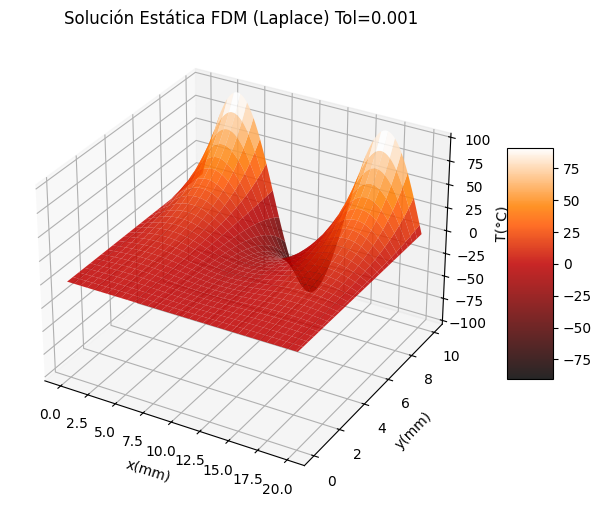

In [17]:
a = 20.0   # Ancho mm
b = 10.0   # Alto mm
D = 84.0   # Difusividad térmica mm^2/s

Nx = 101
Ny = 51

x = np.linspace(0, a, Nx)
y = np.linspace(0, b, Ny)
dx = x[1] - x[0]

tol = 1e-3
V_ini = np.zeros((Ny, Nx), float)

V_ini[-1, :] = 100.0 * np.sin(3.0 * np.pi * x / a)

start = tm.process_time()
V_estatico, iters, error = Laplace2D_FDM(V_ini, tol)
end = tm.process_time()

X, Y, Z = grid(V_estatico, x, y)

print(f'Tiempo ejecución estático (s) = {end - start:.4f}')
print(f'Iteraciones = {iters}')
print(f'Error = {error:.6f}')

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='gist_heat', alpha=0.85)
ax.set_title(f'Solución Estática FDM (Laplace) Tol={tol}')
ax.set_xlabel('x(mm)')
ax.set_ylabel('y(mm)')
ax.set_zlabel('T(°C)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

2. Compare the *static solution* with the analytical one.

Diferencia máxima con Solución Analítica = 0.2932 °C


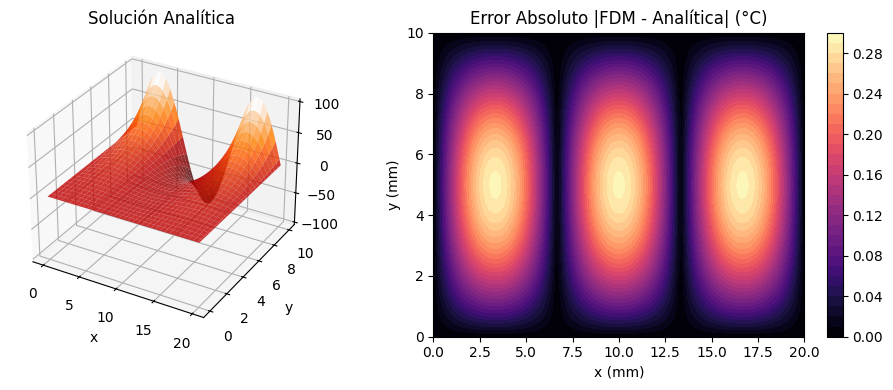

In [ ]:
Z_analitico = 100.0 * (np.sinh(3 * np.pi * Y / a) / np.sinh(3 * np.pi * b / a)) * np.sin(3 * np.pi * X / a)
error_absoluto = np.abs(Z - Z_analitico)

print(f'Diferencia máxima con Solución Analítica = {np.max(error_absoluto):.4f} °C')

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(122)
contour = ax1.contourf(X, Y, error_absoluto, levels=30, cmap='magma')
ax1.set_title('Error Absoluto |FDM - Analítica| (°C)')
ax1.set_xlabel('x(mm)')
ax1.set_ylabel('y(mm)')
fig.colorbar(contour, ax=ax1)

ax2 = fig.add_subplot(121, projection='3d')
ax2.plot_surface(X, Y, Z_analitico, cmap='gist_heat', alpha=0.8)
ax2.set_title('Solución Analítica')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
plt.tight_layout()
plt.show()

3. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
4. Do a gif for the temperature in time (bonus!)

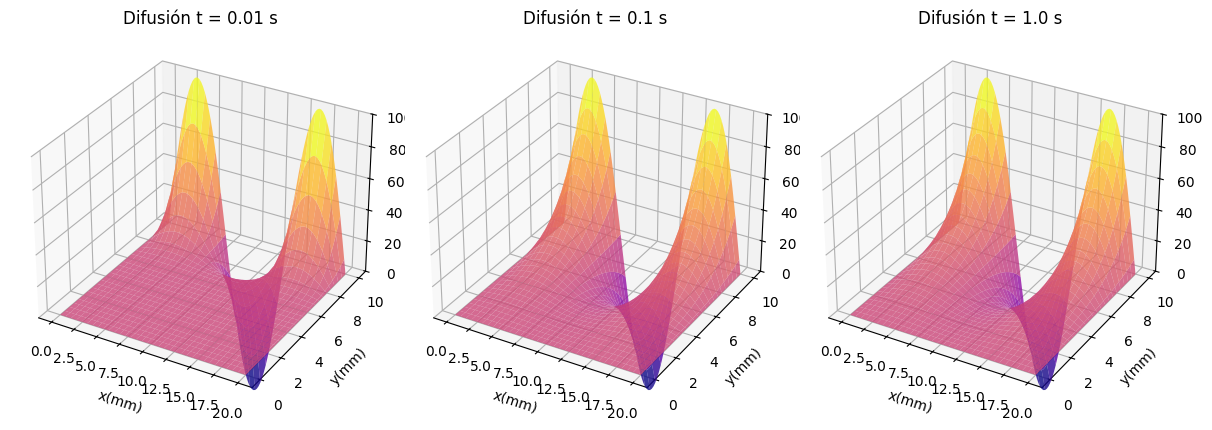

In [20]:
dt = 0.9 * (dx**2) / (4 * D) 
tiempos = [0.01,0.1,1.0]

fig = plt.figure(figsize=(12,6))

for idx, t_final in enumerate(tiempos):
    V_transitorio = Diffusion2D_FDM(V_ini, D, dx, dt, t_final)
    _, _, Z_trans = grid(V_transitorio, x, y)
    
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.plot_surface(X, Y, Z_trans, cmap='plasma', alpha=0.8)
    ax.set_title(f'Difusión t = {t_final} s')
    ax.set_xlabel('x(mm)')
    ax.set_ylabel('y(mm)')
    ax.set_zlim(0, 100)

plt.tight_layout()
plt.show()